## Installing and Importing Required Libraries

In [6]:
!pip install -q python-dotenv
!pip install -q anthropic

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import base64
import os
import requests
import json
import re

import anthropic
from dotenv import load_dotenv
load_dotenv()

True

## Importing the Dataset

In [13]:
dataset = pd.read_csv("heart_disease_uci.csv", encoding='utf-8')

keep_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
             'restecg', 'thalch', 'exang', 'oldpeak', 'num']
dataset = dataset[keep_cols].dropna().reset_index(drop=True)

# Convert the multi-class target to a binary heart disease flag
dataset['heart_disease'] = (dataset['num'] > 0).astype(int)

print(dataset.shape)
dataset.head()

(740, 12)


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num,heart_disease
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0,0


## Inserting Data in GridDB

### Creating a GridDB Connection

In [14]:
username = os.environ.get("username")
password = os.environ.get("password")
base_url = os.environ.get("base_url")


url = f"{base_url}/checkConnection"

credentials = f"{username}:{password}"
encoded_credentials = base64.b64encode(credentials.encode()).decode()

headers = {
    'Content-Type': 'application/json',
    'Authorization': f'Basic {encoded_credentials}',
    'User-Agent': 'PostmanRuntime/7.29.0'
}

response = requests.get(url, headers=headers)

print(response.status_code)

200


### Creating a GridDB Container for Patient Records

In [15]:
dataset.insert(0, "SerialNo", dataset.index + 1)
dataset.columns.name = None

# Mapping pandas dtypes to GridDB types
type_mapping = {
    "int64":      "LONG",
    "float64":    "DOUBLE",
    "bool":       "BOOL",
    "datetime64": "TIMESTAMP",
    "object":     "STRING",
    "category":   "STRING",
}

# Generate the columns part of the payload dynamically
columns = []
for col, dtype in dataset.dtypes.items():
    griddb_type = type_mapping.get(str(dtype), "STRING")
    columns.append({
        "name": col,
        "type": griddb_type
    })

print(columns)

[{'name': 'SerialNo', 'type': 'LONG'}, {'name': 'age', 'type': 'LONG'}, {'name': 'sex', 'type': 'STRING'}, {'name': 'cp', 'type': 'STRING'}, {'name': 'trestbps', 'type': 'DOUBLE'}, {'name': 'chol', 'type': 'DOUBLE'}, {'name': 'fbs', 'type': 'STRING'}, {'name': 'restecg', 'type': 'STRING'}, {'name': 'thalch', 'type': 'DOUBLE'}, {'name': 'exang', 'type': 'STRING'}, {'name': 'oldpeak', 'type': 'DOUBLE'}, {'name': 'num', 'type': 'LONG'}, {'name': 'heart_disease', 'type': 'LONG'}]


In [16]:
container_name = "heart_disease_db"

url = f"{base_url}/containers"

payload = json.dumps({
    "container_name": container_name,
    "container_type": "COLLECTION",
    "rowkey": True,
    "columns": columns
})

response = requests.post(url, headers=headers, data=payload)

print(f"Status Code: {response.status_code}")

Status Code: 201


### Inserting Patient Records into the GridDB Container

In [17]:
url = f"{base_url}/containers/{container_name}/rows"

def format_row(row):
    formatted = []
    for item in row:
        if pd.isna(item):
            formatted.append(None)
        elif isinstance(item, bool):
            formatted.append(str(item).lower())
        elif isinstance(item, (int, float)):
            formatted.append(item)
        else:
            formatted.append(str(item))
    return formatted

rows = [format_row(row) for row in dataset.values.tolist()]

payload = json.dumps(rows)

response = requests.put(url, headers=headers, data=payload)

print(f"Status Code: {response.status_code}")
print(f"Response Text: {response.text}")

Status Code: 200
Response Text: {"count":740}


## Using AI to Analyze Patient Records and Get Insights

### Retrieve Data from GridDB

In [18]:
url = f"{base_url}/containers/{container_name}/rows"

payload = json.dumps({
    "offset": 0,
    "limit": 10000,
    "condition": "",
    "sort": ""
})

response = requests.post(url, headers=headers, data=payload)

print(f"Status Code: {response.status_code}")
if response.status_code == 200:
    try:
        data = response.json()
        print("Data retrieved successfully!")

        rows = data.get("rows", [])
        heart_disease_db = pd.DataFrame(rows, columns=[col for col in dataset.columns])

    except json.JSONDecodeError:
        print("Error: Failed to decode JSON response.")
else:
    print(f"Error: Failed to query data from the container. Response: {response.text}")

print(heart_disease_db.shape)
heart_disease_db.head()

Status Code: 200
Data retrieved successfully!
(740, 13)


,SerialNo,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num,heart_disease
0,1,63,Male,typical angina,145.0,233.0,true,lv hypertrophy,150.0,false,2.3,0,0
1,2,67,Male,asymptomatic,160.0,286.0,false,lv hypertrophy,108.0,true,1.5,2,1
2,3,67,Male,asymptomatic,120.0,229.0,false,lv hypertrophy,129.0,true,2.6,1,1
3,4,37,Male,non-anginal,130.0,250.0,false,normal,187.0,false,3.5,0,0
4,5,41,Female,atypical angina,130.0,204.0,false,lv hypertrophy,172.0,false,1.4,0,0


### Build Dataset Summary

In [19]:
NUMERIC_COLS = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

STAGE_LABELS = {
    0: 'stage 0 (no disease)',
    1: 'stage 1',
    2: 'stage 2',
    3: 'stage 3',
    4: 'stage 4'
}

def build_summary(df):
    parts = []

    # Overview
    total = len(df)
    diseased = int(df['heart_disease'].sum())
    healthy = total - diseased
    parts.append(f"Records: {total} patients")
    parts.append(f"Heart disease present (num > 0): {diseased} ({diseased/total*100:.1f}%)")
    parts.append(f"No heart disease (num = 0): {healthy} ({healthy/total*100:.1f}%)")

    # Stage breakdown using the original num column (0 to 4)
    stage_counts = df['num'].value_counts().sort_index()
    stage_table = pd.DataFrame({
        'patients': stage_counts,
        'pct': (stage_counts / total * 100).round(1)
    })
    stage_table.index = [STAGE_LABELS.get(int(i), str(i)) for i in stage_table.index]
    parts.append(f"\n--- Heart Disease Stage Distribution (num column) ---\n{stage_table.to_string()}")

    # Sex distribution
    sex_counts = df['sex'].value_counts()
    parts.append(f"\n--- Sex Distribution ---\n{sex_counts.to_string()}")

    # Numeric stats overall
    parts.append(f"\n--- Numeric Stats (overall) ---\n{df[NUMERIC_COLS].describe().round(2).to_string()}")

    # Numeric stats split by heart disease status
    grouped = df.groupby('heart_disease')[NUMERIC_COLS].mean().round(2)
    grouped.index = ['no disease', 'disease']
    parts.append(f"\n--- Avg by Heart Disease Status ---\n{grouped.to_string()}")

    # Numeric stats split by stage (0 to 4)
    stage_grouped = df.groupby('num')[NUMERIC_COLS].mean().round(2)
    stage_grouped.index = [STAGE_LABELS.get(int(i), str(i)) for i in stage_grouped.index]
    parts.append(f"\n--- Avg by Stage ---\n{stage_grouped.to_string()}")

    # Chest pain type vs disease (cp is already a string in the Kaggle file:
    # typical angina, atypical angina, non-anginal, asymptomatic)
    cp_counts = df.groupby('cp')['heart_disease'].agg(['count', 'sum'])
    cp_counts['rate_pct'] = (cp_counts['sum'] / cp_counts['count'] * 100).round(1)
    parts.append(f"\n--- Chest Pain Type vs Disease ---\n{cp_counts.to_string()}")

    # Chest pain type vs stage (cross tab)
    stage_named = df['num'].map(STAGE_LABELS)
    cp_stage = pd.crosstab(df['cp'], stage_named)
    parts.append(f"\n--- Chest Pain Type vs Stage (counts) ---\n{cp_stage.to_string()}")

    # Age groups
    bins = [0, 40, 50, 60, 70, 100]
    labels = ['<40', '40-49', '50-59', '60-69', '70+']
    df_local = df.copy()
    df_local['age_group'] = pd.cut(df_local['age'], bins=bins, labels=labels, right=False)
    age_stats = df_local.groupby('age_group').agg(
        patients=('age', 'count'),
        disease_count=('heart_disease', 'sum'),
        avg_stage=('num', 'mean'),
        avg_chol=('chol', 'mean'),
        avg_bp=('trestbps', 'mean'),
        avg_max_hr=('thalch', 'mean')
    ).round(2)
    age_stats['disease_rate_pct'] = (age_stats['disease_count'] / age_stats['patients'] * 100).round(1)
    parts.append(f"\n--- Age Group Breakdown ---\n{age_stats.to_string()}")

    # Sex vs disease
    sex_stats = df.groupby('sex')['heart_disease'].agg(['count', 'sum'])
    sex_stats['rate_pct'] = (sex_stats['sum'] / sex_stats['count'] * 100).round(1)
    parts.append(f"\n--- Sex vs Disease ---\n{sex_stats.to_string()}")

    # High cholesterol flag
    df_local['high_chol'] = df_local['chol'] >= 240
    chol_stats = df_local.groupby('high_chol')['heart_disease'].agg(['count', 'sum'])
    chol_stats['rate_pct'] = (chol_stats['sum'] / chol_stats['count'] * 100).round(1)
    chol_stats.index = ['chol < 240', 'chol >= 240']
    parts.append(f"\n--- High Cholesterol vs Disease ---\n{chol_stats.to_string()}")

    # Exercise-induced angina
    exang_stats = df.groupby('exang')['heart_disease'].agg(['count', 'sum'])
    exang_stats['rate_pct'] = (exang_stats['sum'] / exang_stats['count'] * 100).round(1)
    parts.append(f"\n--- Exercise-Induced Angina vs Disease ---\n{exang_stats.to_string()}")

    return "\n".join(parts)


data_summary = build_summary(heart_disease_db)
print(data_summary[:600])

Records: 740 patients
Heart disease present (num > 0): 383 (51.8%)
No heart disease (num = 0): 357 (48.2%)

--- Heart Disease Stage Distribution (num column) ---
                      patients   pct
stage 0 (no disease)       357  48.2
stage 1                    204  27.6
stage 2                     79  10.7
stage 3                     78  10.5
stage 4                     22   3.0

--- Sex Distribution ---
sex
Male      566
Female    174

--- Numeric Stats (overall) ---
          age  trestbps    chol  thalch  oldpeak
count  740.00    740.00  740.00  740.00   740.00
mean    53.10    132.75  22


/tmp/ipykernel_17137/2023547795.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df_local.groupby('age_group').agg(


### Creating Chatbot

In [20]:
SYSTEM_PROMPT = f"""You are a clinical data analyst. You have records for {len(heart_disease_db)} patients
from the UCI Heart Disease dataset. Each record includes age, sex, chest pain type (cp),
resting blood pressure (trestbps), cholesterol (chol), fasting blood sugar (fbs),
resting ECG (restecg), maximum heart rate achieved (thalch), exercise-induced angina (exang),
and ST depression (oldpeak). The heart_disease column is 1 when disease is present and 0 otherwise.

Always ground your answers in the specific numbers from the summary below. When you give
recommendations, frame them as data-backed observations rather than medical advice, and remind
the user that any clinical decision should be reviewed by a qualified healthcare professional.

DATA:
{data_summary}
"""


class HeartDiseaseChatbot:
    def __init__(self):
        self.client = anthropic.Anthropic()
        self.history = []

    def ask(self, question):
        self.history.append({"role": "user", "content": question})
        response = self.client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=2048,
            system=SYSTEM_PROMPT,
            messages=self.history
        )
        answer = response.content[0].text
        self.history.append({"role": "assistant", "content": answer})
        return answer

    def reset(self):
        self.history = []
        print("History cleared.")


chatbot = HeartDiseaseChatbot()
print("Chatbot ready!")

Chatbot ready!


### Ask Questions

In [21]:
# Q1: Most common risk factors among heart disease patients
print(chatbot.ask("Which risk factors appear most often among patients who have heart disease? Cite specific numbers."))

# Key Risk Factors Associated with Heart Disease in This Dataset

Here is a breakdown of the factors most strongly associated with heart disease presence across the 383 affected patients (51.8% of the 740 total). All figures come directly from the data summary.

---

## 1. 🫀 Exercise-Induced Angina — Strongest Single Predictor
- Patients **with** exercise-induced angina had a disease rate of **81.8%** (242 of 296 patients)
- Patients **without** it had a rate of only **31.8%** (141 of 444)
- That is a **50 percentage-point gap**, making this the sharpest dividing factor in the dataset

---

## 2. 💔 Chest Pain Type (Asymptomatic = High Risk)
- **Asymptomatic** chest pain had by far the highest disease rate: **76.0%** (298 of 392 patients)
- Compare that to **atypical angina** at only **14.7%** (22 of 150) and **non-anginal pain** at **30.4%** (49 of 161)
- Counterintuitively, the *absence* of classic symptoms was most strongly linked to disease presence

---

## 3. 👴 Age — Clear Gradien

In [22]:
# Q2: Age group comparison
print(chatbot.ask("Compare heart disease rates across age groups. How do the average cholesterol and resting blood pressure shift with age?"))

# Heart Disease, Cholesterol & Blood Pressure Across Age Groups

Here is a detailed breakdown using the exact figures from the dataset of 740 patients.

---

## 📊 Heart Disease Rate by Age Group — A Clear Escalation

| Age Group | Patients | Disease Cases | Disease Rate | Avg Stage |
|-----------|----------|---------------|--------------|-----------|
| Under 40 | 66 | 18 | 27.3% | 0.35 |
| 40–49 | 182 | 72 | 39.6% | 0.54 |
| 50–59 | 304 | 161 | 53.0% | 0.91 |
| 60–69 | 165 | 116 | 70.3% | 1.50 |
| 70+ | 23 | 16 | 69.6% | 1.65 |

### Key Observations:
- Disease rate **more than doubles** from the under-40 group (27.3%) to the 60–69 group (70.3%)
- The steepest single jump occurs between **50–59 (53.0%) and 60–69 (70.3%)** — a **17.3 percentage point** leap
- The **70+ group** (69.6%) is slightly lower than 60–69, but this group has only **23 patients**, making it the smallest and least statistically robust cohort
- Average disease stage also rises consistently, from **0.35** in the youn

In [23]:
# Q3: Follow-up
print(chatbot.ask("Based on what you just told me, which single feature would be the most useful early warning sign for a clinician to focus on?"))

# Most Useful Single Early Warning Feature: A Data-Driven Assessment

This is an important question, and the data offers a reasonably clear answer — though with important nuances worth unpacking.

---

## 🏆 The Strongest Single Indicator: Exercise-Induced Angina

Based purely on the numbers in this dataset, **exercise-induced angina (exang)** produces the sharpest, cleanest separation between disease and non-disease patients:

- Patients **with** exercise-induced angina: **81.8% disease rate** (242 of 296)
- Patients **without** it: **31.8% disease rate** (141 of 444)
- That is a **50 percentage-point gap** — larger than any other single binary factor in the dataset

No other individual feature creates this magnitude of split.

---

## 📊 How Other Strong Candidates Compare

| Feature | Key Finding | Limitation |
|--------|-------------|------------|
| **Exercise-induced angina** | 81.8% vs 31.8% disease rate | Requires an exercise test to measure |
| **Asymptomatic chest pain** | 76.0%

### Execute Code and Generate Charts

In [ ]:

client = anthropic.Anthropic()

def generate_and_run_chart(question):
    """
    Ask Claude to generate matplotlib code for a chart, then execute it.
    The chart displays inline in the notebook.
    """
    schema = f"Columns: {list(heart_disease_db.columns)}\nSample:\n{heart_disease_db.head(3).to_csv(index=False)}"

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=2048,
        messages=[{
            "role": "user",
            "content": f"""I have a pandas DataFrame `heart_disease_db` with this structure:

{schema}

The heart_disease column is 1 if disease is present and 0 otherwise.
Chest pain type (cp) is a string column with values: 'typical angina', 'atypical angina', 'non-anginal', 'asymptomatic'.

Write Python code using pandas and matplotlib to: {question}

RULES:
- Return ONLY Python code, no markdown fences, no explanation
- heart_disease_db is already loaded, matplotlib.pyplot is imported as plt
- Use plt.figure(figsize=(10, 6)) for good sizing
- Always include plt.tight_layout() and plt.show()
- Add a clear title, axis labels, and a legend where needed"""
        }]
    )

    code = response.content[0].text
    code = re.sub(r'^```python\s*', '', code, flags=re.MULTILINE)
    code = re.sub(r'^```\s*$', '', code, flags=re.MULTILINE)
    code = code.strip()

    print("Generated code:")
    print("-" * 40)
    print(code)
    print("-" * 40)
    print("\nExecuting...\n")

    exec(code, globals())



Generated code:
----------------------------------------
age_bins = [0, 39, 49, 59, 69, float('inf')]
age_labels = ['<40', '40-49', '50-59', '60-69', '70+']

heart_disease_db['age_group'] = pd.cut(heart_disease_db['age'], bins=age_bins, labels=age_labels, right=True)

age_group_stats = heart_disease_db.groupby('age_group', observed=True)['heart_disease'].agg(['sum', 'count']).reset_index()
age_group_stats.columns = ['age_group', 'disease_count', 'total_count']
age_group_stats['percentage'] = (age_group_stats['disease_count'] / age_group_stats['total_count']) * 100

plt.figure(figsize=(10, 6))

bars = plt.bar(
    age_group_stats['age_group'],
    age_group_stats['percentage'],
    color='steelblue',
    edgecolor='black',
    width=0.6
)

for bar, pct in zip(bars, age_group_stats['percentage']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight

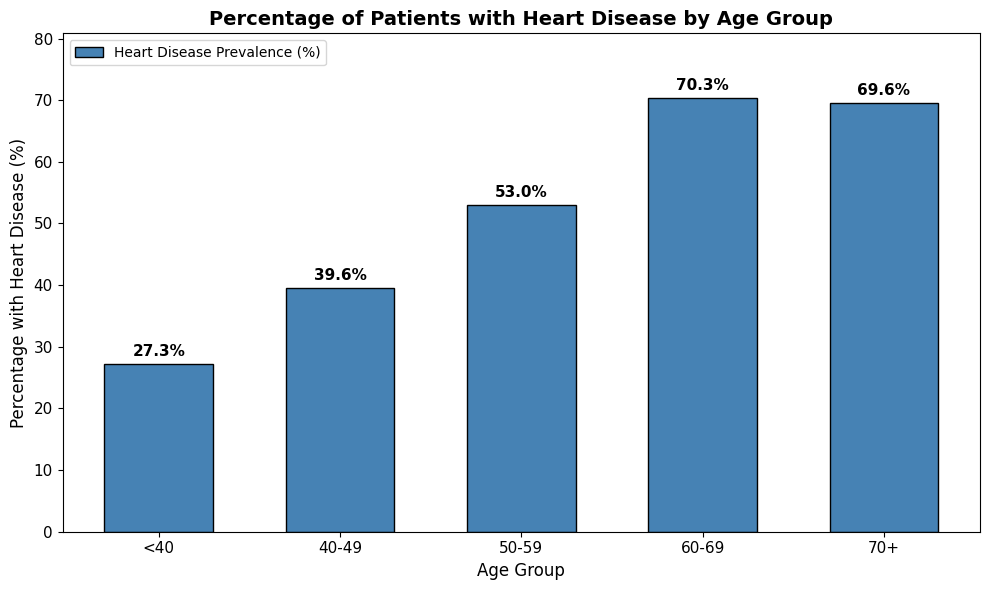

In [25]:
# Chart 1: Disease rate by age group
generate_and_run_chart("Bar chart showing the percentage of patients with heart disease across age groups (<40, 40-49, 50-59, 60-69, 70+). Put the percentage on top of each bar.")

Generated code:
----------------------------------------
cp_order = ['typical angina', 'atypical angina', 'non-anginal pain', 'asymptomatic']

cp_disease = heart_disease_db.groupby('cp')['heart_disease'].agg(['sum', 'count'])
cp_disease['percentage'] = (cp_disease['sum'] / cp_disease['count']) * 100
cp_disease = cp_disease.reindex(cp_order)

plt.figure(figsize=(10, 6))
bars = plt.bar(cp_order, cp_disease['percentage'], color=['steelblue', 'darkorange', 'green', 'red'], edgecolor='black', width=0.6)

for bar, pct in zip(bars, cp_disease['percentage']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Percentage of Patients with Heart Disease by Chest Pain Type', fontsize=14, fontweight='bold')
plt.xlabel('Chest Pain Type', fontsize=12)
plt.ylabel('Percentage with Heart Disease (%)', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, 100)
plt.legend(handles=bars

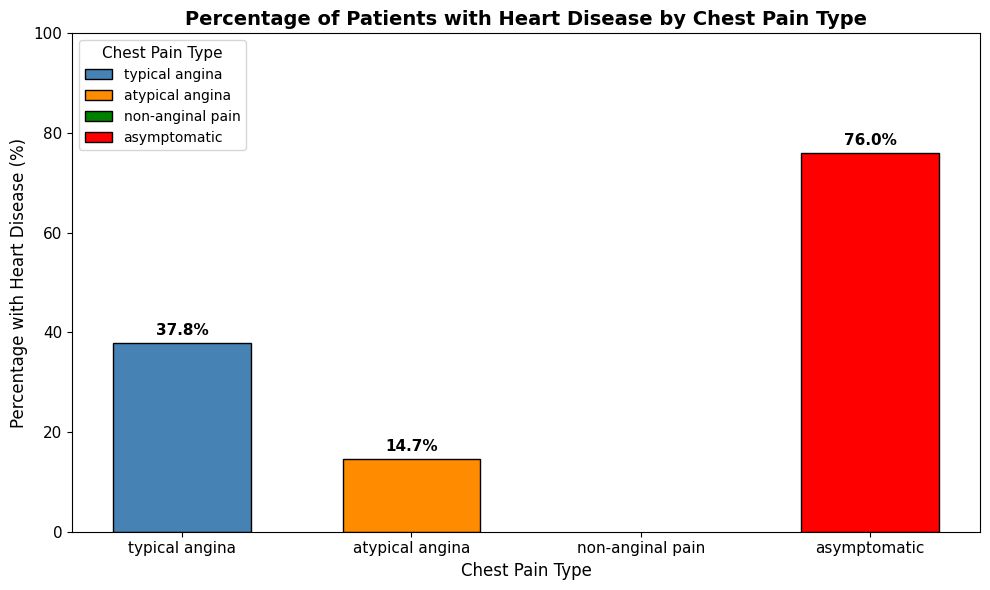

In [26]:
# Chart 2: Disease rate by chest pain type
generate_and_run_chart("Bar chart showing the percentage of patients with heart disease for each chest pain type. Use the labels typical angina, atypical angina, non-anginal, asymptomatic on the x axis.")

Generated code:
----------------------------------------
plt.figure(figsize=(10, 6))

chol_disease = heart_disease_db[heart_disease_db['heart_disease'] == 1]['chol'].dropna()
chol_no_disease = heart_disease_db[heart_disease_db['heart_disease'] == 0]['chol'].dropna()

plt.hist(chol_no_disease, bins=30, color='steelblue', alpha=0.6, label='No Heart Disease')
plt.hist(chol_disease, bins=30, color='tomato', alpha=0.6, label='Heart Disease')

plt.title('Cholesterol Distribution by Heart Disease Status')
plt.xlabel('Cholesterol (mg/dl)')
plt.ylabel('Number of Patients')
plt.legend()

plt.tight_layout()
plt.show()
----------------------------------------

Executing...



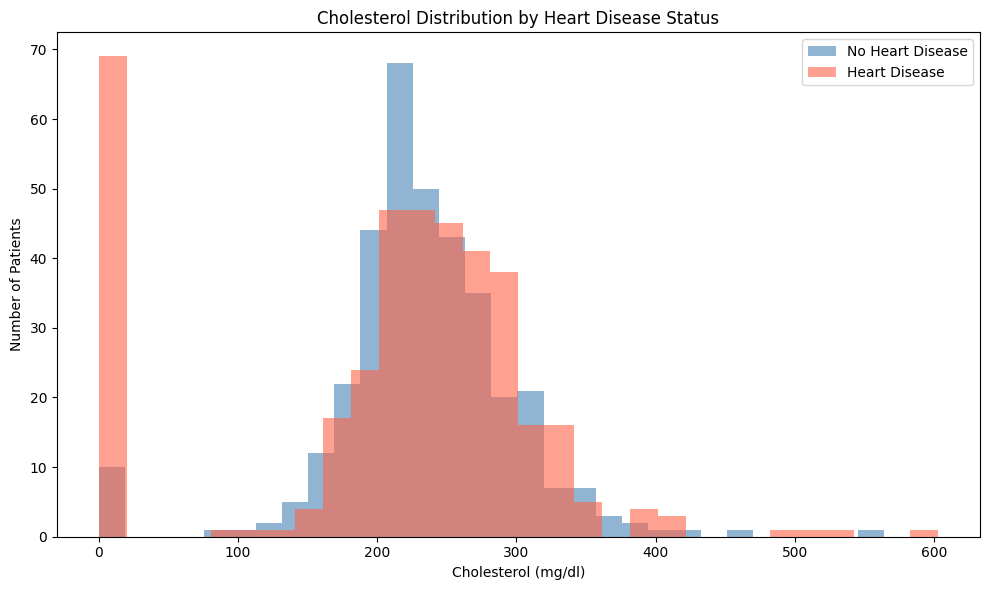

In [27]:
# Chart 3: Cholesterol distribution by disease status
generate_and_run_chart("Two overlapping histograms of cholesterol values, one for patients with heart disease and one for patients without. Use different colors and add a legend.")